# Next-Word Prediction: Model Comparison

Compares **SimpleRNN**, **LSTM** and **GRU** on the same data, the same split, the same hyperparameters and the same seed. Only the recurrent layer changes, so any difference is down to the architecture.

`03_lstm.ipynb` and `04_gru.ipynb` must be run first. Any model missing from `outputs/metrics.json` is trained here (set `TRAIN_MISSING = False` to skip that).

## 1. Setup

In [1]:
import os
import sys
sys.path.append(os.path.abspath(".."))  # so `import config` and `from src...` work from notebooks/

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

import config
from src.dataset import load_corpus, prepare_data
from src.preprocess import Vocabulary, clean_text, split_sentences, tokenize

np.random.seed(config.RANDOM_STATE)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})

print("TensorFlow:", tf.__version__)
print("Corpus:", config.DEFAULT_CORPUS)
print("Outputs:", config.OUTPUTS_DIR)

TensorFlow: 2.21.0
Corpus: D:\next-word-prediction\data\raw\corpus.txt
Outputs: D:\next-word-prediction\outputs


In [2]:
TRAIN_MISSING = True  # train any model that has no results yet (SimpleRNN is trained here if needed)

## 2. Collect results

In [4]:
from src.train import train

metrics_path = config.OUTPUTS_DIR / "metrics.json"
metrics = json.loads(metrics_path.read_text()) if metrics_path.exists() else {}

for kind in config.MODEL_KINDS:
    if kind not in metrics and TRAIN_MISSING:
        print(f"--- training missing model: {kind}")
        train(
            kind,
            config.DEFAULT_CORPUS,
            epochs=8,
            batch_size=256,
            seq_len=5,
            embed_dim=64,
            units=64,
            verbose=2,
        )
        metrics = json.loads(metrics_path.read_text())

labels = {"rnn": "SimpleRNN", "lstm": "LSTM", "gru": "GRU"}
df = pd.DataFrame(metrics).T.loc[[k for k in config.MODEL_KINDS if k in metrics]]
df = df[["parameters", "top1_accuracy", "top5_accuracy", "perplexity", "test_loss", "train_seconds", "epochs_run", "best_epoch"]]
df.index = [labels[k] for k in df.index]
df

--- training missing model: rnn
Data: {"vocab_size": 10000, "train_samples": 986726, "val_samples": 122588, "test_samples": 123465, "seq_len": 5}


Model: "next_word_rnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 5, 64)          │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embed_dropout (Dropout)         │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn (SimpleRNN)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_dropout (Dropout)           │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ next_word_probs (Dense)         │ (None, 10000)          │       650,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,298,256 (4.95 MB)

 Trainable params: 1,298,256 (4.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
3855/3855 - 169s - 44ms/step - loss: 6.4026 - top1_accuracy: 0.1065 - top5_accuracy: 0.2481 - val_loss: 5.9392 - val_top1_accuracy: 0.1338 - val_top5_accuracy: 0.2891 - learning_rate: 0.0010
Epoch 2/8
3855/3855 - 467s - 121ms/step - loss: 6.0126 - top1_accuracy: 0.1286 - top5_accuracy: 0.2829 - val_loss: 5.7884 - val_top1_accuracy: 0.1430 - val_top5_accuracy: 0.3058 - learning_rate: 0.0010
Epoch 3/8
3855/3855 - 439s - 114ms/step - loss: 5.8992 - top1_accuracy: 0.1356 - top5_accuracy: 0.2931 - val_loss: 5.7192 - val_top1_accuracy: 0.1485 - val_top5_accuracy: 0.3131 - learning_rate: 0.0010
Epoch 4/8
3855/3855 - 171s - 44ms/step - loss: 5.8338 - top1_accuracy: 0.1385 - top5_accuracy: 0.2983 - val_loss: 5.6767 - val_top1_accuracy: 0.1518 - val_top5_accuracy: 0.3183 - learning_rate: 0.0010
Epoch 5/8
3855/3855 - 262s - 68ms/step - loss: 5.7831 - top1_accuracy: 0.1412 - top5_accuracy: 0.3026 - val_loss: 5.6415 - val_top1_accuracy: 0.1534 - val_top5_accuracy: 0.3210 - learning_rate: 

,parameters,top1_accuracy,top5_accuracy,perplexity,test_loss,train_seconds,epochs_run,best_epoch
SimpleRNN,1298256,0.1557,0.3248,269.8,5.5977,2043.7,8,8
LSTM,1323024,0.1552,0.3221,278.49,5.6294,2841.4,8,8
GRU,1314960,0.1576,0.3289,261.52,5.5665,2032.4,8,8


## 3. Comparison table

In [10]:
def md_table(frame):
    header = ["Model", "Parameters", "Top-1 accuracy", "Top-5 accuracy", "Perplexity", "Training time"]
    lines = ["| " + " | ".join(header) + " |", "|" + "|".join(["---"] * len(header)) + "|"]
    for name, r in frame.sort_values("perplexity").iterrows():
        minutes, seconds = divmod(int(r.train_seconds), 60)
        time_str = f"{minutes}m {seconds:02d}s"
        lines.append(
            f"| {name} | {int(r.parameters):,} | {r.top1_accuracy:.2%} | "
            f"{r.top5_accuracy:.2%} | {r.perplexity:.2f} | {time_str} |"
        )
    return "\n".join(lines)

table = md_table(df)
(config.OUTPUTS_DIR / "results.md").write_text(table + "\n", encoding="utf-8")
print(table)
print("\nSaved to outputs/results.md: paste this table into the README.")

| Model | Parameters | Top-1 accuracy | Top-5 accuracy | Perplexity | Training time |
|---|---|---|---|---|---|
| GRU | 1,314,960 | 15.76% | 32.89% | 261.52 | 33m 52s |
| SimpleRNN | 1,298,256 | 15.57% | 32.48% | 269.80 | 34m 03s |
| LSTM | 1,323,024 | 15.52% | 32.21% | 278.49 | 47m 21s |

Saved to outputs/results.md: paste this table into the README.


## 4. Charts

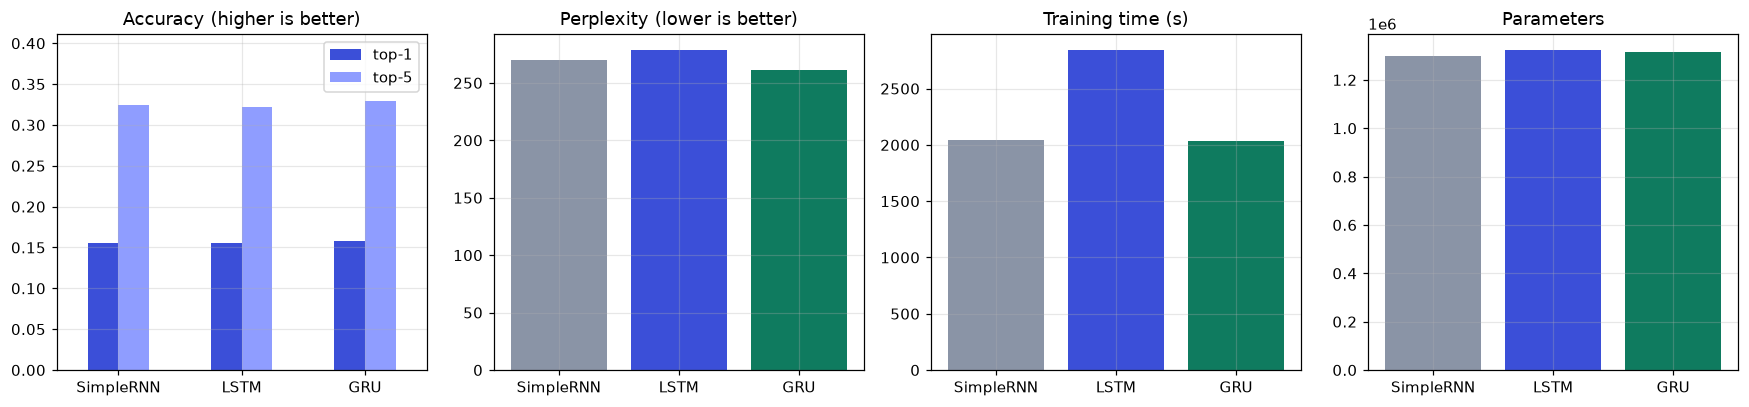

In [14]:
%matplotlib inline
fig, axes = plt.subplots(1, 4, figsize=(16, 3.8))
colors = ["#8a94a6", "#3b4fd8", "#0f7b5f"][: len(df)]

acc = df[["top1_accuracy", "top5_accuracy"]]
acc.plot.bar(ax=axes[0], rot=0, color=["#3b4fd8", "#8f9dff"])
axes[0].set(title="Accuracy (higher is better)", ylim=(0, min(1, acc.values.max() * 1.25)))
axes[0].legend(["top-1", "top-5"])

for ax, col, title in zip(axes[1:], ["perplexity", "train_seconds", "parameters"],
                          ["Perplexity (lower is better)", "Training time (s)", "Parameters"]):
    ax.bar(df.index, df[col], color=colors)
    ax.set(title=title)
fig.tight_layout()
fig.savefig(config.OUTPUTS_DIR / "model_comparison.png", dpi=150)
plt.show()

## 5. Training curves side by side

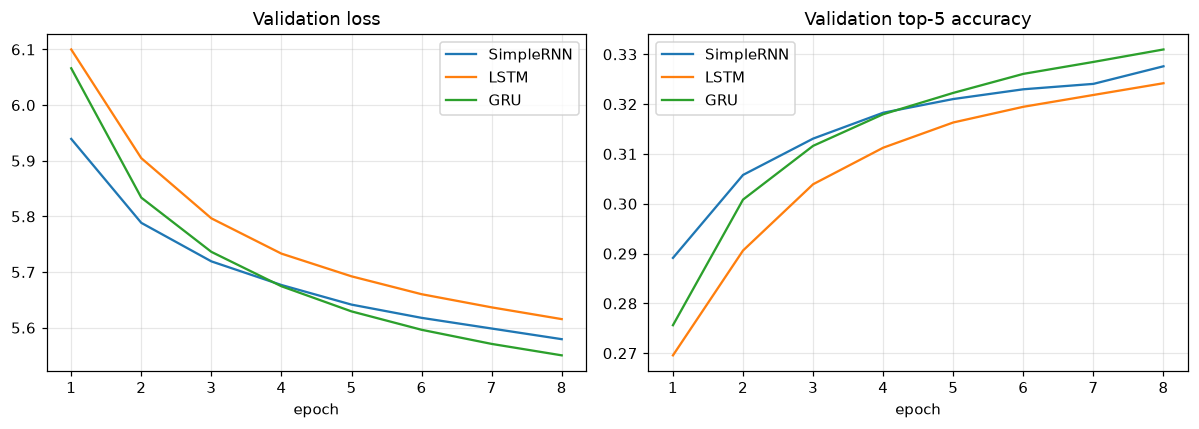

In [15]:
%matplotlib inline
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for kind in [k for k in config.MODEL_KINDS if k in metrics]:
    h = json.loads((config.OUTPUTS_DIR / f"{kind}_history.json").read_text())
    axes[0].plot(range(1, len(h["val_loss"]) + 1), h["val_loss"], label=labels[kind])
    axes[1].plot(range(1, len(h["val_top5_accuracy"]) + 1), h["val_top5_accuracy"], label=labels[kind])
axes[0].set(title="Validation loss", xlabel="epoch")
axes[1].set(title="Validation top-5 accuracy", xlabel="epoch")
for ax in axes:
    ax.legend()
fig.tight_layout()
fig.savefig(config.OUTPUTS_DIR / "validation_curves_comparison.png", dpi=150)
plt.show()

## 6. Same prompts, three models

In [16]:
from src.predict import Predictor

prompts = ["i want to go to the ", "it is a ", "holmes was ", "what do you "]
predictors = {k: Predictor.load(config.MODELS_DIR / f"{k}.keras", config.VOCAB_PATH) for k in metrics}

rows = []
for p in prompts:
    row = {"prompt": p.strip()}
    for k, pr in predictors.items():
        row[labels[k]] = ", ".join(s["word"] for s in pr.predict_next(p, 5))
    rows.append(row)
pd.set_option("display.max_colwidth", 80)
pd.DataFrame(rows).set_index("prompt")

,LSTM,GRU,SimpleRNN
prompt,,,
i want to go to the,"same, first, new, way, world","end, same, world, new, top","same, next, top, first, new"
it is a,"lot, little, good, few, bit","lot, good, little, great, few","lot, little, good, few, bit"
holmes was,"a, the, in, not, an","a, the, in, an, not","a, the, in, an, on"
what do you,"know, have, want, get, are","have, know, get, do, want","know, have, get, want, can"


## 7. Pick the production model

The deciding metric is **perplexity on the test set** (top-5 accuracy is what users feel). Training time and size break ties.

In [17]:
best = df["perplexity"].idxmin()
best_key = {v: k for k, v in labels.items()}[best]
print(f"Lowest perplexity: {best}  ->  set PRODUCTION_MODEL={best_key} (models/{best_key}.keras)")
print("Fastest to train  :", df["train_seconds"].idxmin())
print("Smallest          :", df["parameters"].idxmin())

Lowest perplexity: GRU  ->  set PRODUCTION_MODEL=gru (models/gru.keras)
Fastest to train  : GRU
Smallest          : SimpleRNN


## 8. Conclusions

Fill these in from **your** numbers above, do not copy assumptions:

- Which model has the lowest perplexity, and by how much over the runner-up?
- Is the gap between LSTM and GRU larger than run-to-run noise? (Re-run with another seed if unsure.)
- What does the extra training time or parameter count of each model buy you?
- Which model is deployed, and why? (`PRODUCTION_MODEL` environment variable or `config.py`.)